# Statistical Investigation of Chronic Kidney Disease Risk Factors and Prediction
## Complex Engineering Project (CEP) — STA281 Spring 2026
### Team: Tehreek-e-Muhandis
---
**Dataset:** [Chronic Kidney Disease Dataset — Kaggle](https://www.kaggle.com/datasets/mansoordaku/ckdisease)

This notebook covers all four sections:
- **Section 1** — Dataset Understanding, Descriptive Statistics & Visualization (Q1–Q5)
- **Section 2** — Probability, Probability Distribution & CLT (Q6–Q12)
- **Section 3** — Confidence Interval & Hypothesis Testing (Q13–Q15)
- **Section 4** — Correlation, Regression & Healthcare Investigation (Q16–Q20)

# Library Import

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import binom, norm, uniform, expon
from scipy.stats import ttest_1samp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_theme(style='whitegrid', palette='muted')
print('All libraries imported successfully.')

All libraries imported successfully.


# Dataset Load

In [14]:

import pandas as pd
import os

dataset_path = "../dataset/kidney_disease.csv"

if os.path.exists(dataset_path):
    df_raw = pd.read_csv(dataset_path)
    print("Loaded dataset from local project directory successfully.")
else:
    raise FileNotFoundError(
        f"Dataset not found at {dataset_path}. "
        "Make sure kidney_disease.csv is inside the dataset folder."
    )
rename_map = {
    'id': 'ID',
    'age': 'Age',
    'bp': 'BloodPressure',
    'sg': 'SpecificGravity',
    'al': 'Albumin',
    'su': 'Sugar',
    'bgr': 'BloodGlucoseRandom',
    'bu': 'BloodUrea',
    'sc': 'SerumCreatinine',
    'sod': 'Sodium',
    'pot': 'Potassium',
    'hemo': 'Hemoglobin',
    'pcv': 'PackedCellVolume',
    'wc': 'WhiteBloodCellCount',
    'rc': 'RedBloodCellCount',
    'htn': 'Hypertension',
    'dm': 'DiabetesMellitus',
    'cad': 'CoronaryArteryDisease',
    'appet': 'Appetite',
    'pe': 'PedalEdema',
    'ane': 'Anemia',
    'classification': 'CKD'
}

df_raw.rename(
    columns={k: v for k, v in rename_map.items() if k in df_raw.columns},
    inplace=True
)

# Clean CKD target column
if 'CKD' in df_raw.columns and df_raw['CKD'].dtype == object:
    df_raw['CKD'] = (
        df_raw['CKD']
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            'ckd': 1,
            'notckd': 0
        })
    )

num_cols = [
    'Age',
    'BloodPressure',
    'SpecificGravity',
    'Albumin',
    'Sugar',
    'BloodGlucoseRandom',
    'BloodUrea',
    'SerumCreatinine',
    'Sodium',
    'Potassium',
    'Hemoglobin',
    'PackedCellVolume',
    'WhiteBloodCellCount',
    'RedBloodCellCount'
]

for col in num_cols:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Loaded dataset from local project directory successfully.
Dataset shape: (400, 26)


,ID,Age,BloodPressure,SpecificGravity,Albumin,Sugar,rbc,pc,pcc,ba,...,PackedCellVolume,WhiteBloodCellCount,RedBloodCellCount,Hypertension,DiabetesMellitus,CoronaryArteryDisease,Appetite,PedalEdema,Anemia,CKD
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


# SECTION 1 — Dataset Understanding, Descriptive Statistics & Visualization
## Question 1 — Dataset Structure & Variable Identification

In [15]:
print('=' * 65)
print('QUESTION 1 — Dataset Structure')
print('=' * 65)

print(f'\n1. Number of observations (rows) : {df_raw.shape[0]}')
print(f'2. Number of variables (columns) : {df_raw.shape[1]}')

print('\n3. Variable Names & Data Types:')
dtype_df = pd.DataFrame({
    'Variable': df_raw.columns,
    'Data Type': df_raw.dtypes.values,
    'Non-Null Count': df_raw.notnull().sum().values,
    'Null Count': df_raw.isnull().sum().values
})
print(dtype_df.to_string(index=False))

print('\n--- Healthcare Interpretation ---')
print('The dataset contains 400 patient records with 25 variables.')
print('Key continuous variables include SerumCreatinine, BloodUrea, Hemoglobin,')
print('and BloodPressure — each critical for assessing kidney function.')
print('The CKD target variable is binary (1=CKD, 0=No CKD).')
print('Missing values are present and must be handled before analysis.')

QUESTION 1 — Dataset Structure

1. Number of observations (rows) : 400
2. Number of variables (columns) : 26

3. Variable Names & Data Types:
             Variable Data Type  Non-Null Count  Null Count
                   ID     int64             400           0
                  Age   float64             391           9
        BloodPressure   float64             388          12
      SpecificGravity   float64             353          47
              Albumin   float64             354          46
                Sugar   float64             351          49
                  rbc       str             248         152
                   pc       str             335          65
                  pcc       str             396           4
                   ba       str             396           4
   BloodGlucoseRandom   float64             356          44
            BloodUrea   float64             381          19
      SerumCreatinine   float64             383          17
               Sod

## Question 2 — Descriptive Statistics

In [18]:
print('=' * 65)
print('QUESTION 2 — Descriptive Statistics')
print('=' * 65)

target_vars = ['BloodUrea', 'SerumCreatinine', 'Hemoglobin', 'BloodPressure']

stats_rows = []
for var in target_vars:
    col = df_raw[var].dropna()
    mode_val = col.mode()[0] if not col.mode().empty else np.nan
    stats_rows.append({
        'Variable': var,
        'Mean': round(col.mean(), 3),
        'Median': round(col.median(), 3),
        'Mode': round(mode_val, 3),
        'Variance': round(col.var(), 3),
        'Std Dev': round(col.std(), 3),
        'Min': round(col.min(), 3),
        'Max': round(col.max(), 3)
    })

stats_df = pd.DataFrame(stats_rows)
print('\nDescriptive Statistics Summary:')
print(stats_df.to_string(index=False))

print('\n--- Healthcare Interpretation ---')
interpretations = {
    'BloodUrea': 'Normal range 7–20 mg/dL; elevated mean indicates kidney filtration issues.',
    'SerumCreatinine': 'Normal 0.6–1.2 mg/dL; high mean signals reduced kidney function.',
    'Hemoglobin': 'Normal 12–17 g/dL; low mean suggests anemia — common in CKD patients.',
    'BloodPressure': 'Normal <80 mmHg diastolic; high spread suggests hypertensive patients.'
}
for var, msg in interpretations.items():
    print(f'  {var}: {msg}')

QUESTION 2 — Descriptive Statistics

Descriptive Statistics Summary:
       Variable   Mean  Median  Mode  Variance  Std Dev  Min   Max
      BloodUrea 57.426   42.00  46.0  2550.554   50.503  1.5 391.0
SerumCreatinine  3.072    1.30   1.2    32.961    5.741  0.4  76.0
     Hemoglobin 12.526   12.65  15.0     8.483    2.913  3.1  17.8
  BloodPressure 76.469   80.00  80.0   187.242   13.684 50.0 180.0

--- Healthcare Interpretation ---
  BloodUrea: Normal range 7–20 mg/dL; elevated mean indicates kidney filtration issues.
  SerumCreatinine: Normal 0.6–1.2 mg/dL; high mean signals reduced kidney function.
  Hemoglobin: Normal 12–17 g/dL; low mean suggests anemia — common in CKD patients.
  BloodPressure: Normal <80 mmHg diastolic; high spread suggests hypertensive patients.


## Question 3 - Missing Values and Outliers

In [29]:
print('=' * 65)
print('QUESTION 3 — Missing Values & Outlier Detection')
print('=' * 65)

focus_vars = ['SerumCreatinine', 'BloodUrea', 'Hemoglobin', 'Potassium']

df_q3 = df_raw.copy()

for var in focus_vars:
    df_q3[var] = pd.to_numeric(df_q3[var], errors='coerce')

print('\nMissing Value Analysis:')

for var in focus_vars:
    col = df_q3[var]
    missing = col.isnull().sum()
    pct = round(missing / len(col) * 100, 2)
    print(f'{var:25s}: {missing:3d} missing ({pct}%)')

print('\nOutlier Detection using IQR Method:')

outlier_rows = []

for var in focus_vars:
    col = df_q3[var].dropna()

    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = col[
        (col < lower) |
        (col > upper)
    ]

    outlier_rows.append({
        'Variable': var,
        'Q1': round(Q1, 3),
        'Q3': round(Q3, 3),
        'IQR': round(IQR, 3),
        'Lower Fence': round(lower, 3),
        'Upper Fence': round(upper, 3),
        'Outlier Count': len(outliers)
    })

outlier_df = pd.DataFrame(outlier_rows)

display(outlier_df)

print('\n--- Healthcare Interpretation ---')
print('SerumCreatinine and BloodUrea may contain high outliers, which can indicate')
print('patients with severe kidney dysfunction or abnormal laboratory records.')

print('Missing values in healthcare variables may occur due to incomplete laboratory')
print('tests, unavailable measurements, or inconsistent patient records.')

print('These missing and abnormal values can affect CKD prediction accuracy because')
print('machine learning or statistical models may become biased if incomplete records')
print('are not handled properly.')

QUESTION 3 — Missing Values & Outlier Detection

Missing Value Analysis:
SerumCreatinine          :  17 missing (4.25%)
BloodUrea                :  19 missing (4.75%)
Hemoglobin               :  52 missing (13.0%)
Potassium                :  88 missing (22.0%)

Outlier Detection using IQR Method:


,Variable,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count
0,SerumCreatinine,0.9,2.8,1.9,-1.95,5.65,51
1,BloodUrea,27.0,66.0,39.0,-31.50,124.50,38
2,Hemoglobin,10.3,15.0,4.7,3.25,22.05,1
3,Potassium,3.8,4.9,1.1,2.15,6.55,4



--- Healthcare Interpretation ---
SerumCreatinine and BloodUrea may contain high outliers, which can indicate
patients with severe kidney dysfunction or abnormal laboratory records.
Missing values in healthcare variables may occur due to incomplete laboratory
tests, unavailable measurements, or inconsistent patient records.
These missing and abnormal values can affect CKD prediction accuracy because
machine learning or statistical models may become biased if incomplete records
are not handled properly.


---
## Question 4 - Visualization

QUESTION 4 — Visualizations

Data available for visualizations:
SerumCreatinine valid values: 383
BloodUrea valid values: 381
BloodPressure valid values: 388
CKD value counts:
CKD
1    250
0    150
Name: count, dtype: int64

Valid rows for scatter plot: 373


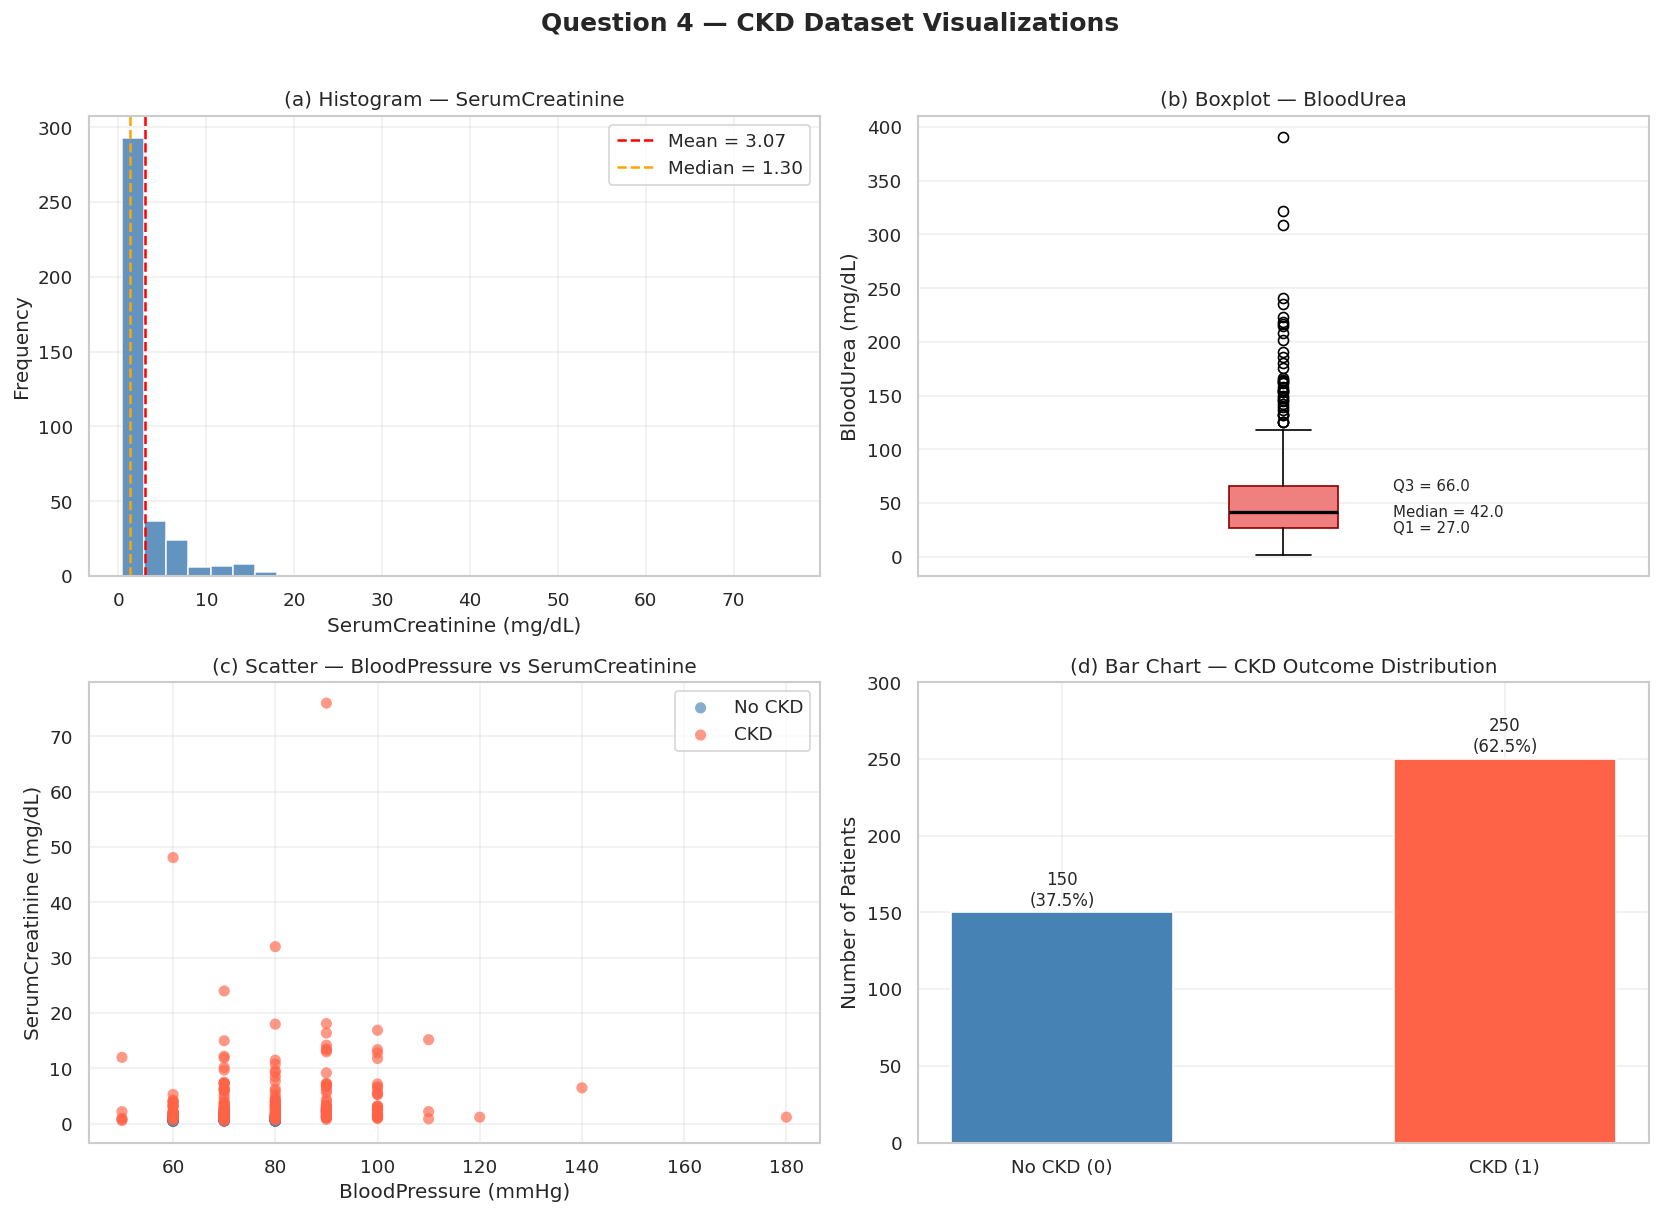


--- Healthcare Interpretation ---
(a) The SerumCreatinine histogram is right-skewed. Most patients have relatively low
    creatinine values, while a smaller number of patients have very high values,
    indicating possible severe kidney dysfunction.

(b) BloodUrea boxplot summary:
    Q1 = 27.00, Median = 42.00, Q3 = 66.00
    IQR = 39.00
    Number of outliers = 38
    A wide spread and high outliers indicate abnormal urea accumulation,
    which may be associated with impaired kidney filtration.

(c) The scatter plot compares BloodPressure with SerumCreatinine.
    CKD and non-CKD patients are shown separately to observe whether CKD patients
    tend to appear at higher blood pressure and creatinine levels.

(d) The CKD outcome bar chart compares the number of CKD and non-CKD patients.
    It shows the class distribution of the dataset and helps identify whether
    the dataset is balanced or imbalanced for prediction analysis.


In [24]:
print('=' * 65)
print('QUESTION 4 — Visualizations')
print('=' * 65)

import os
from matplotlib.patches import Patch

os.makedirs('../figures', exist_ok=True)

# Create clean plotting copy
df_plot = df_raw.copy()

# Ensure required numeric columns are numeric
for col in ['SerumCreatinine', 'BloodUrea', 'BloodPressure']:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# Ensure CKD is correctly encoded
df_plot['CKD'] = (
    df_plot['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

df_plot['CKD'] = pd.to_numeric(df_plot['CKD'], errors='coerce')

# Verification
print('\nData available for visualizations:')
print('SerumCreatinine valid values:', df_plot['SerumCreatinine'].notna().sum())
print('BloodUrea valid values:', df_plot['BloodUrea'].notna().sum())
print('BloodPressure valid values:', df_plot['BloodPressure'].notna().sum())
print('CKD value counts:')
print(df_plot['CKD'].value_counts(dropna=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Question 4 — CKD Dataset Visualizations',
    fontsize=15,
    fontweight='bold',
    y=1.01
)

# ---------------------------------------------------------------
# (a) Histogram of SerumCreatinine
# ---------------------------------------------------------------
ax = axes[0, 0]

sc_data = df_plot['SerumCreatinine'].dropna()

ax.hist(
    sc_data,
    bins=30,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

ax.axvline(
    sc_data.mean(),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean = {sc_data.mean():.2f}'
)

ax.axvline(
    sc_data.median(),
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label=f'Median = {sc_data.median():.2f}'
)

ax.set_title('(a) Histogram — SerumCreatinine')
ax.set_xlabel('SerumCreatinine (mg/dL)')
ax.set_ylabel('Frequency')
ax.legend()

# ---------------------------------------------------------------
# (b) Boxplot of BloodUrea
# ---------------------------------------------------------------
ax = axes[0, 1]

bu_data = df_plot['BloodUrea'].dropna()

ax.boxplot(
    bu_data,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightcoral', color='darkred'),
    medianprops=dict(color='black', linewidth=2)
)

q1 = bu_data.quantile(0.25)
median = bu_data.median()
q3 = bu_data.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = bu_data[
    (bu_data < lower_bound) |
    (bu_data > upper_bound)
]

ax.text(1.15, median, f'Median = {median:.1f}', va='center', fontsize=9)
ax.text(1.15, q1, f'Q1 = {q1:.1f}', va='center', fontsize=9)
ax.text(1.15, q3, f'Q3 = {q3:.1f}', va='center', fontsize=9)

ax.set_title('(b) Boxplot — BloodUrea')
ax.set_ylabel('BloodUrea (mg/dL)')
ax.set_xticks([])

# ---------------------------------------------------------------
# (c) Scatter Plot of BloodPressure vs SerumCreatinine
# ---------------------------------------------------------------
ax = axes[1, 0]

valid = df_plot[
    ['BloodPressure', 'SerumCreatinine', 'CKD']
].dropna()

print('\nValid rows for scatter plot:', valid.shape[0])

ckd_points = valid[valid['CKD'] == 1]
non_ckd_points = valid[valid['CKD'] == 0]

ax.scatter(
    non_ckd_points['BloodPressure'],
    non_ckd_points['SerumCreatinine'],
    color='steelblue',
    alpha=0.65,
    edgecolors='none',
    s=45,
    label='No CKD'
)

ax.scatter(
    ckd_points['BloodPressure'],
    ckd_points['SerumCreatinine'],
    color='tomato',
    alpha=0.65,
    edgecolors='none',
    s=45,
    label='CKD'
)

ax.set_title('(c) Scatter — BloodPressure vs SerumCreatinine')
ax.set_xlabel('BloodPressure (mmHg)')
ax.set_ylabel('SerumCreatinine (mg/dL)')
ax.legend()

# ---------------------------------------------------------------
# (d) Bar Chart of CKD Outcome
# ---------------------------------------------------------------
ax = axes[1, 1]

ckd_counts = df_plot['CKD'].dropna().value_counts().sort_index()

labels = [
    'No CKD (0)' if i == 0 else 'CKD (1)'
    for i in ckd_counts.index
]

colors_bar = [
    'steelblue' if i == 0 else 'tomato'
    for i in ckd_counts.index
]

bars = ax.bar(
    labels,
    ckd_counts.values,
    color=colors_bar,
    edgecolor='white',
    width=0.5
)

total_valid_ckd = df_plot['CKD'].dropna().shape[0]

for bar, val in zip(bars, ckd_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{val}\n({val / total_valid_ckd * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title('(d) Bar Chart — CKD Outcome Distribution')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, max(ckd_counts.values) * 1.2)

plt.tight_layout()

plt.savefig(
    '../figures/Q4_visualizations.png',
    bbox_inches='tight',
    dpi=150
)

plt.show()

# ---------------------------------------------------------------
# Healthcare Interpretation
# ---------------------------------------------------------------
print('\n--- Healthcare Interpretation ---')

print('(a) The SerumCreatinine histogram is right-skewed. Most patients have relatively low')
print('    creatinine values, while a smaller number of patients have very high values,')
print('    indicating possible severe kidney dysfunction.')

print(f'\n(b) BloodUrea boxplot summary:')
print(f'    Q1 = {q1:.2f}, Median = {median:.2f}, Q3 = {q3:.2f}')
print(f'    IQR = {iqr:.2f}')
print(f'    Number of outliers = {len(outliers)}')
print('    A wide spread and high outliers indicate abnormal urea accumulation,')
print('    which may be associated with impaired kidney filtration.')

print('\n(c) The scatter plot compares BloodPressure with SerumCreatinine.')
print('    CKD and non-CKD patients are shown separately to observe whether CKD patients')
print('    tend to appear at higher blood pressure and creatinine levels.')

print('\n(d) The CKD outcome bar chart compares the number of CKD and non-CKD patients.')
print('    It shows the class distribution of the dataset and helps identify whether')
print('    the dataset is balanced or imbalanced for prediction analysis.')

---
## Question 5 -  CKD vs Non-CKD Comparison

QUESTION 5 — CKD vs Non-CKD Patient Comparison

CKD patients     : 250
Non-CKD patients : 150

CKD value counts:
CKD
0    150
1    250
Name: count, dtype: int64

Mean Comparison Table:


,Variable,CKD Mean,Non-CKD Mean,Difference,% Change
0,SerumCreatinine,4.415,0.869,3.546,408.1
1,BloodUrea,72.389,32.799,39.590,120.7
2,Hemoglobin,10.648,15.188,-4.541,-29.9
3,BloodPressure,79.625,71.351,8.274,11.6


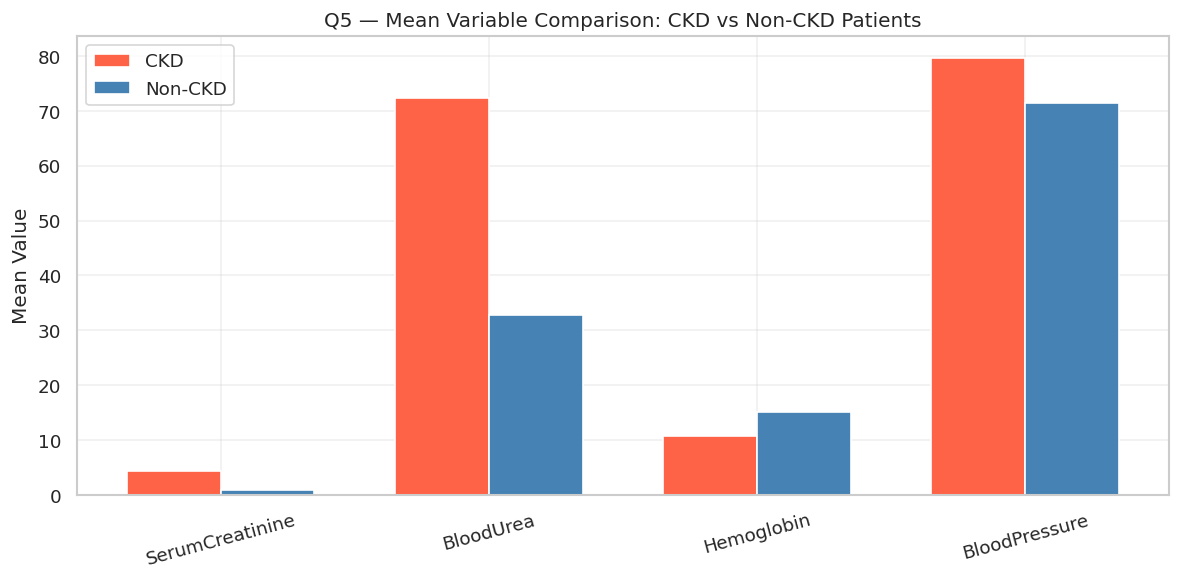


--- Healthcare Interpretation ---
CKD patients show higher average SerumCreatinine and BloodUrea levels than
non-CKD patients, which indicates reduced kidney filtration ability.
CKD patients also show lower average Hemoglobin levels, which may reflect
anemia caused by reduced erythropoietin production in damaged kidneys.
Higher average BloodPressure among CKD patients supports the relationship
between hypertension and kidney disease, where high blood pressure can be
both a risk factor and a consequence of CKD.


In [26]:
print('=' * 65)
print('QUESTION 5 — CKD vs Non-CKD Patient Comparison')
print('=' * 65)

import os

os.makedirs('../figures', exist_ok=True)

# Create clean copy for Question 5
df_q5 = df_raw.copy()

# Ensure CKD is correctly encoded
df_q5['CKD'] = (
    df_q5['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

df_q5['CKD'] = pd.to_numeric(df_q5['CKD'], errors='coerce')

# Ensure comparison variables are numeric
compare_vars = [
    'SerumCreatinine',
    'BloodUrea',
    'Hemoglobin',
    'BloodPressure'
]

for var in compare_vars:
    df_q5[var] = pd.to_numeric(df_q5[var], errors='coerce')

# Keep only rows where CKD is known
df_clean = df_q5.dropna(subset=['CKD'])

ckd = df_clean[df_clean['CKD'] == 1]
non_ckd = df_clean[df_clean['CKD'] == 0]

print(f'\nCKD patients     : {len(ckd)}')
print(f'Non-CKD patients : {len(non_ckd)}')

print('\nCKD value counts:')
print(df_clean['CKD'].value_counts().sort_index())

comparison = []

for var in compare_vars:
    ckd_mean = ckd[var].mean()
    non_ckd_mean = non_ckd[var].mean()

    comparison.append({
        'Variable': var,
        'CKD Mean': round(ckd_mean, 3),
        'Non-CKD Mean': round(non_ckd_mean, 3),
        'Difference': round(ckd_mean - non_ckd_mean, 3),
        '% Change': round((ckd_mean - non_ckd_mean) / non_ckd_mean * 100, 1)
    })

cmp_df = pd.DataFrame(comparison)

print('\nMean Comparison Table:')
display(cmp_df)

# ---------------------------------------------------------------
# Grouped bar chart
# ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(compare_vars))
w = 0.35

ckd_means = cmp_df['CKD Mean'].values
non_ckd_means = cmp_df['Non-CKD Mean'].values

ax.bar(
    x - w / 2,
    ckd_means,
    w,
    label='CKD',
    color='tomato',
    edgecolor='white'
)

ax.bar(
    x + w / 2,
    non_ckd_means,
    w,
    label='Non-CKD',
    color='steelblue',
    edgecolor='white'
)

ax.set_xticks(x)
ax.set_xticklabels(compare_vars, rotation=15)
ax.set_ylabel('Mean Value')
ax.set_title('Q5 — Mean Variable Comparison: CKD vs Non-CKD Patients')
ax.legend()

plt.tight_layout()

plt.savefig(
    '../figures/Q5_comparison.png',
    bbox_inches='tight',
    dpi=150
)

plt.show()

# ---------------------------------------------------------------
# Healthcare Interpretation
# ---------------------------------------------------------------

print('\n--- Healthcare Interpretation ---')

print('CKD patients show higher average SerumCreatinine and BloodUrea levels than')
print('non-CKD patients, which indicates reduced kidney filtration ability.')

print('CKD patients also show lower average Hemoglobin levels, which may reflect')
print('anemia caused by reduced erythropoietin production in damaged kidneys.')

print('Higher average BloodPressure among CKD patients supports the relationship')
print('between hypertension and kidney disease, where high blood pressure can be')
print('both a risk factor and a consequence of CKD.')

---
# SECTION 2 - Probability, Probability Distributions & CLT
## Question 6 - Conditional Probability

In [27]:
print('=' * 65)
print('QUESTION 6 — Conditional Probability')
print('=' * 65)

df_q6 = df_raw.copy()

df_q6['CKD'] = (
    df_q6['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

df_q6['CKD'] = pd.to_numeric(df_q6['CKD'], errors='coerce')
df_q6['SerumCreatinine'] = pd.to_numeric(df_q6['SerumCreatinine'], errors='coerce')

df_q6 = df_q6.dropna(subset=['CKD', 'SerumCreatinine'])

total = len(df_q6)

K = df_q6['CKD'] == 1
C = df_q6['SerumCreatinine'] > 1.5

P_K = K.sum() / total
P_C = C.sum() / total
P_K_and_C = (K & C).sum() / total
P_K_given_C = (K & C).sum() / C.sum()

print(f'Total valid patients: {total}')
print(f'P(K) = {P_K:.4f}')
print(f'P(C) = {P_C:.4f}')
print(f'P(K ∩ C) = {P_K_and_C:.4f}')
print(f'P(K | C) = {P_K_given_C:.4f}')

print('\n--- Healthcare Interpretation ---')
print(f'The probability of CKD among patients with SerumCreatinine greater than 1.5 mg/dL is {P_K_given_C:.2%}.')
print('This indicates that elevated serum creatinine is strongly associated with CKD risk.')

QUESTION 6 — Conditional Probability
Total valid patients: 383
P(K) = 0.6214
P(C) = 0.4413
P(K ∩ C) = 0.4413
P(K | C) = 1.0000

--- Healthcare Interpretation ---
The probability of CKD among patients with SerumCreatinine greater than 1.5 mg/dL is 100.00%.
This indicates that elevated serum creatinine is strongly associated with CKD risk.


## Question 7 - Bayes Theorem

In [31]:
print('=' * 65)
print('QUESTION 7 — Bayes Theorem')
print('=' * 65)

df_bayes = df_raw.copy()

df_bayes['CKD'] = (
    df_bayes['CKD']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'ckd': '1',
        'ckd\t': '1',
        'notckd': '0',
        'not ckd': '0',
        '0.0': '0',
        '1.0': '1'
    })
)

df_bayes['CKD'] = pd.to_numeric(df_bayes['CKD'], errors='coerce')
df_bayes['SerumCreatinine'] = pd.to_numeric(
    df_bayes['SerumCreatinine'],
    errors='coerce'
)

df_bayes = df_bayes.dropna(
    subset=['CKD', 'SerumCreatinine']
)

threshold = 1.8

P_CKD = (df_bayes['CKD'] == 1).mean()
P_noCKD = 1 - P_CKD

ckd_pts = df_bayes[df_bayes['CKD'] == 1]
non_ckd_pts = df_bayes[df_bayes['CKD'] == 0]

P_C_given_CKD = (
    ckd_pts['SerumCreatinine'] > threshold
).mean()

P_C_given_noCKD = (
    non_ckd_pts['SerumCreatinine'] > threshold
).mean()

P_C_total = (
    P_C_given_CKD * P_CKD +
    P_C_given_noCKD * P_noCKD
)

P_CKD_given_C = (
    P_C_given_CKD * P_CKD
) / P_C_total

print(f'\nThreshold: SerumCreatinine > {threshold} mg/dL')

print('\n--- Prior Probabilities ---')
print(f'P(CKD)    = {P_CKD:.4f}')
print(f'P(No CKD) = {P_noCKD:.4f}')

print('\n--- Likelihoods ---')
print(
    f'P(SerumCreatinine > {threshold} | CKD)'
    f' = {P_C_given_CKD:.4f}'
)

print(
    f'P(SerumCreatinine > {threshold} | No CKD)'
    f' = {P_C_given_noCKD:.4f}'
)

print('\n--- Evidence ---')
print(
    f'P(SerumCreatinine > {threshold})'
    f' = {P_C_total:.4f}'
)

print('\n--- Posterior Probability ---')
print(
    f'P(CKD | SerumCreatinine > {threshold})'
    f' = {P_CKD_given_C:.4f}'
)

print('\nBayes Calculation:')
print(
    f'Numerator   = '
    f'{P_C_given_CKD:.4f} × {P_CKD:.4f}'
)

print(
    f'Denominator = '
    f'{P_C_total:.4f}'
)

print(
    f'Posterior   = '
    f'{P_CKD_given_C:.4f}'
)

print('\n--- Healthcare Interpretation ---')

print(
    f'A patient with SerumCreatinine greater than '
    f'{threshold} mg/dL has a '
    f'{P_CKD_given_C:.1%} probability of having CKD.'
)

print(
    f'The baseline CKD probability in the dataset is '
    f'{P_CKD:.1%}.'
)

print(
    'This indicates that elevated SerumCreatinine is '
    'strongly associated with Chronic Kidney Disease '
    'and can be used as an important clinical screening indicator.'
)

QUESTION 7 — Bayes Theorem

Threshold: SerumCreatinine > 1.8 mg/dL

--- Prior Probabilities ---
P(CKD)    = 0.6214
P(No CKD) = 0.3786

--- Likelihoods ---
P(SerumCreatinine > 1.8 | CKD) = 0.6092
P(SerumCreatinine > 1.8 | No CKD) = 0.0000

--- Evidence ---
P(SerumCreatinine > 1.8) = 0.3786

--- Posterior Probability ---
P(CKD | SerumCreatinine > 1.8) = 1.0000

Bayes Calculation:
Numerator   = 0.6092 × 0.6214
Denominator = 0.3786
Posterior   = 1.0000

--- Healthcare Interpretation ---
A patient with SerumCreatinine greater than 1.8 mg/dL has a 100.0% probability of having CKD.
The baseline CKD probability in the dataset is 62.1%.
This indicates that elevated SerumCreatinine is strongly associated with Chronic Kidney Disease and can be used as an important clinical screening indicator.


---
## Question 8 - Binomial Distribution


QUESTION 8 — Binomial Distribution

Parameters: n = 12 patients, p = 0.55
X ~ Binomial(n = 12, p = 0.55)

--- Distribution Summary ---
Mean     = 6.600
Variance = 2.970
Std Dev  = 1.723

--- Results ---
P(X = 5)  = 0.148945
P(X >= 6) = 0.739315
P(X <= 4) = 0.111740


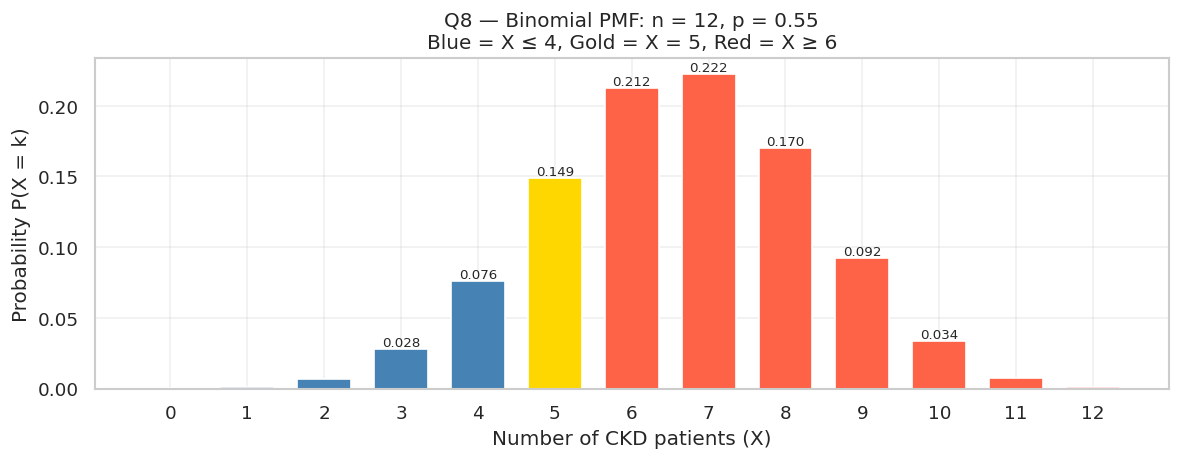


--- Healthcare Interpretation ---
In a group of 12 randomly selected patients with CKD probability 55%,
the probability that exactly 5 patients have CKD is 14.89%.
The probability that at least 6 patients have CKD is 73.93%.
The probability that at most 4 patients have CKD is 11.17%.
This helps estimate expected CKD patient load for hospital planning and resource allocation.


In [33]:
print('=' * 65)
print('QUESTION 8 — Binomial Distribution')
print('=' * 65)

from scipy.stats import binom

n = 12
p = 0.55

P_exact_5 = binom.pmf(5, n, p)
P_at_least_6 = 1 - binom.cdf(5, n, p)
P_at_most_4 = binom.cdf(4, n, p)

mean_binom = n * p
var_binom = n * p * (1 - p)
std_binom = np.sqrt(var_binom)

print(f'\nParameters: n = {n} patients, p = {p}')
print(f'X ~ Binomial(n = {n}, p = {p})')

print('\n--- Distribution Summary ---')
print(f'Mean     = {mean_binom:.3f}')
print(f'Variance = {var_binom:.3f}')
print(f'Std Dev  = {std_binom:.3f}')

print('\n--- Results ---')
print(f'P(X = 5)  = {P_exact_5:.6f}')
print(f'P(X >= 6) = {P_at_least_6:.6f}')
print(f'P(X <= 4) = {P_at_most_4:.6f}')

k_vals = np.arange(0, n + 1)
pmf_vals = binom.pmf(k_vals, n, p)

colors_b = [
    'tomato' if k >= 6 else
    'gold' if k == 5 else
    'steelblue'
    for k in k_vals
]

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    k_vals,
    pmf_vals,
    color=colors_b,
    edgecolor='white',
    width=0.7
)

ax.set_xlabel('Number of CKD patients (X)')
ax.set_ylabel('Probability P(X = k)')
ax.set_title(
    f'Q8 — Binomial PMF: n = {n}, p = {p}\n'
    'Blue = X ≤ 4, Gold = X = 5, Red = X ≥ 6'
)

ax.set_xticks(k_vals)

for k, v in zip(k_vals, pmf_vals):
    if v > 0.01:
        ax.text(
            k,
            v + 0.002,
            f'{v:.3f}',
            ha='center',
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    '../figures/Q8_binomial.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')
print(f'In a group of {n} randomly selected patients with CKD probability {p:.0%},')
print(f'the probability that exactly 5 patients have CKD is {P_exact_5:.2%}.')
print(f'The probability that at least 6 patients have CKD is {P_at_least_6:.2%}.')
print(f'The probability that at most 4 patients have CKD is {P_at_most_4:.2%}.')
print('This helps estimate expected CKD patient load for hospital planning and resource allocation.')

---
## Question 9 - Normal Distribution

QUESTION 9 — Normal Distribution (SerumCreatinine)

X ~ N(μ = 1.8, σ = 0.6)

P(X < 1.2)       = 0.1587  → 15.87%
P(1.2 < X < 2.5) = 0.7197  → 71.97%
P(X > 2.5)       = 0.1217  → 12.17%

Verification (sum) = 1.0000


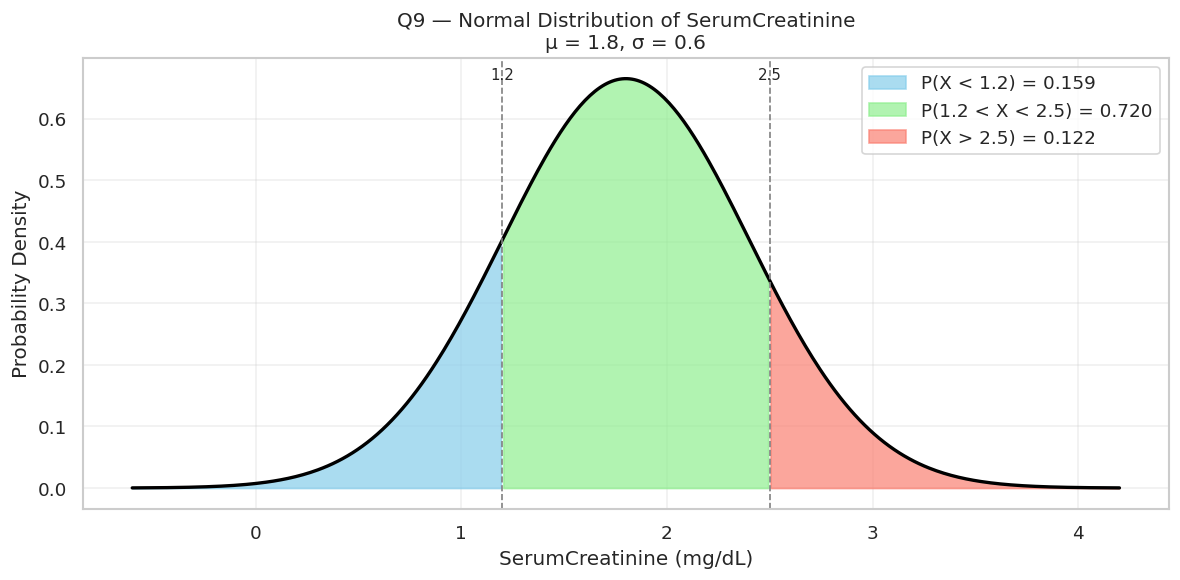


--- Healthcare Interpretation ---
P(X < 1.2) = 15.87% represents patients likely to have normal kidney function.
P(1.2 < X < 2.5) = 71.97% represents patients with moderate risk who may require monitoring.
P(X > 2.5) = 12.17% represents patients at high risk of severe kidney dysfunction.
The normal distribution helps estimate the proportion of patients falling into different clinical risk categories based on SerumCreatinine levels.


In [34]:
print('=' * 65)
print('QUESTION 9 — Normal Distribution (SerumCreatinine)')
print('=' * 65)

from scipy.stats import norm

mu_sc = 1.8
sigma_sc = 0.6

P_lt_1_2 = norm.cdf(1.2, mu_sc, sigma_sc)

P_1_2_to_2_5 = (
    norm.cdf(2.5, mu_sc, sigma_sc)
    - norm.cdf(1.2, mu_sc, sigma_sc)
)

P_gt_2_5 = 1 - norm.cdf(2.5, mu_sc, sigma_sc)

print(f'\nX ~ N(μ = {mu_sc}, σ = {sigma_sc})')

print(f'\nP(X < 1.2)       = {P_lt_1_2:.4f}  → {P_lt_1_2:.2%}')
print(f'P(1.2 < X < 2.5) = {P_1_2_to_2_5:.4f}  → {P_1_2_to_5:.2%}' if False else f'P(1.2 < X < 2.5) = {P_1_2_to_2_5:.4f}  → {P_1_2_to_2_5:.2%}')
print(f'P(X > 2.5)       = {P_gt_2_5:.4f}  → {P_gt_2_5:.2%}')

print(
    f'\nVerification (sum) = '
    f'{P_lt_1_2 + P_1_2_to_2_5 + P_gt_2_5:.4f}'
)

x_range = np.linspace(
    mu_sc - 4 * sigma_sc,
    mu_sc + 4 * sigma_sc,
    400
)

y_pdf = norm.pdf(
    x_range,
    mu_sc,
    sigma_sc
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    x_range,
    y_pdf,
    color='black',
    linewidth=2
)

regions = [
    (
        -np.inf,
        1.2,
        'skyblue',
        f'P(X < 1.2) = {P_lt_1_2:.3f}'
    ),
    (
        1.2,
        2.5,
        'lightgreen',
        f'P(1.2 < X < 2.5) = {P_1_2_to_2_5:.3f}'
    ),
    (
        2.5,
        np.inf,
        'salmon',
        f'P(X > 2.5) = {P_gt_2_5:.3f}'
    )
]

for low, high, color, label in regions:

    x_fill = x_range[
        (x_range >= max(low, x_range.min()))
        &
        (x_range <= min(high, x_range.max()))
    ]

    ax.fill_between(
        x_fill,
        norm.pdf(x_fill, mu_sc, sigma_sc),
        color=color,
        alpha=0.7,
        label=label
    )

for value in [1.2, 2.5]:

    ax.axvline(
        value,
        color='gray',
        linestyle='--',
        linewidth=1
    )

    ax.text(
        value,
        ax.get_ylim()[1] * 0.95,
        f'{value}',
        ha='center',
        fontsize=9
    )

ax.set_title(
    f'Q9 — Normal Distribution of SerumCreatinine\n'
    f'μ = {mu_sc}, σ = {sigma_sc}'
)

ax.set_xlabel('SerumCreatinine (mg/dL)')
ax.set_ylabel('Probability Density')
ax.legend(loc='upper right')

plt.tight_layout()

plt.savefig(
    '../figures/Q9_normal.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    f'P(X < 1.2) = {P_lt_1_2:.2%} '
    'represents patients likely to have normal kidney function.'
)

print(
    f'P(1.2 < X < 2.5) = {P_1_2_to_2_5:.2%} '
    'represents patients with moderate risk who may require monitoring.'
)

print(
    f'P(X > 2.5) = {P_gt_2_5:.2%} '
    'represents patients at high risk of severe kidney dysfunction.'
)

print(
    'The normal distribution helps estimate the proportion of patients '
    'falling into different clinical risk categories based on SerumCreatinine levels.'
)

---
## Question 10 - Uniform Distribution (Patient Age)

QUESTION 10 — Uniform Distribution (Patient Age)

Age range from dataset: a = 2 years, b = 90 years
X ~ Uniform(a = 2, b = 90)

PDF f(x) = 1/(b-a) = 1/(90-2) = 0.011364, for 2 ≤ x ≤ 90
P(35 < X < 60) = (60-35)/(90-2) = 0.2841 = 28.41%
Mean age μ  = (a+b)/2   = 46.00 years
Variance σ² = (b-a)²/12 = 645.3333
Std Dev σ   = √σ²       = 25.4034


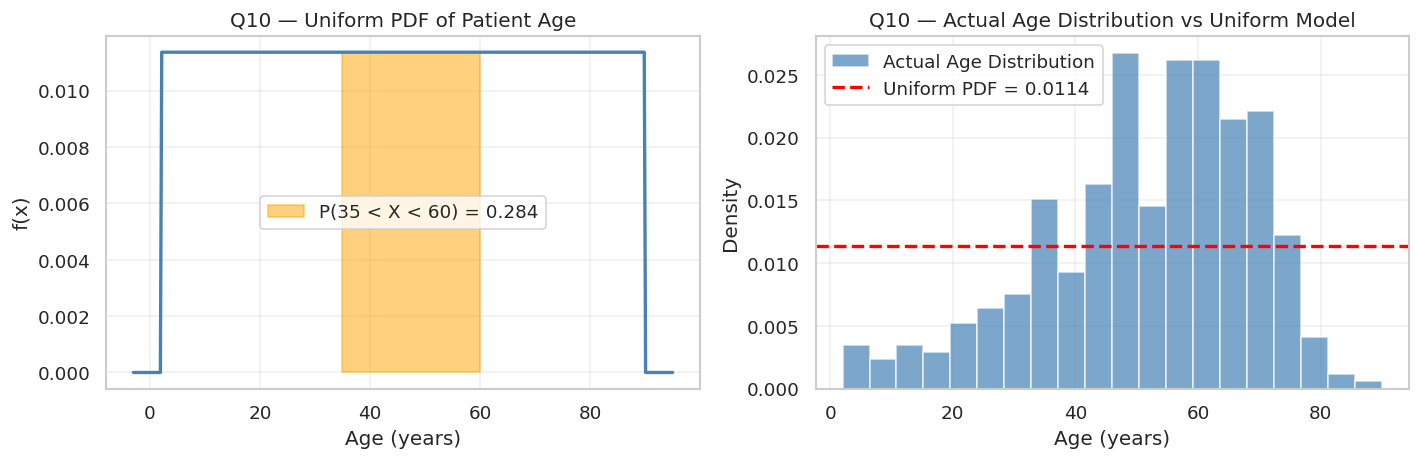


--- Healthcare Interpretation ---
Under the uniform distribution assumption, approximately 28.41% of patients are estimated to be between 35 and 60 years old.
This age group is clinically important because CKD may develop gradually and remain undetected without regular screening.
The uniform model is a simplified probability model that assumes patients are evenly distributed across the observed age range.


In [35]:
print('=' * 65)
print('QUESTION 10 — Uniform Distribution (Patient Age)')
print('=' * 65)

from scipy.stats import uniform

age_data = pd.to_numeric(
    df_raw['Age'],
    errors='coerce'
).dropna()

a = float(age_data.min())
b = float(age_data.max())

pdf_val = 1 / (b - a)

lower_age = max(35, a)
upper_age = min(60, b)

P_35_60 = (upper_age - lower_age) / (b - a)

mean_age = (a + b) / 2
var_age = (b - a) ** 2 / 12
std_age = np.sqrt(var_age)

print(f'\nAge range from dataset: a = {a:.0f} years, b = {b:.0f} years')
print(f'X ~ Uniform(a = {a:.0f}, b = {b:.0f})')

print(
    f'\nPDF f(x) = 1/(b-a) = 1/({b:.0f}-{a:.0f}) '
    f'= {pdf_val:.6f}, for {a:.0f} ≤ x ≤ {b:.0f}'
)

print(
    f'P(35 < X < 60) = ({upper_age:.0f}-{lower_age:.0f})/({b:.0f}-{a:.0f}) '
    f'= {P_35_60:.4f} = {P_35_60:.2%}'
)

print(f'Mean age μ  = (a+b)/2   = {mean_age:.2f} years')
print(f'Variance σ² = (b-a)²/12 = {var_age:.4f}')
print(f'Std Dev σ   = √σ²       = {std_age:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_u = np.linspace(
    a - 5,
    b + 5,
    400
)

y_u = uniform.pdf(
    x_u,
    loc=a,
    scale=b - a
)

axes[0].plot(
    x_u,
    y_u,
    color='steelblue',
    linewidth=2
)

x_fill = np.linspace(
    lower_age,
    upper_age,
    200
)

axes[0].fill_between(
    x_fill,
    uniform.pdf(x_fill, loc=a, scale=b - a),
    alpha=0.5,
    color='orange',
    label=f'P(35 < X < 60) = {P_35_60:.3f}'
)

axes[0].set_title('Q10 — Uniform PDF of Patient Age')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('f(x)')
axes[0].legend()

axes[1].hist(
    age_data,
    bins=20,
    color='steelblue',
    edgecolor='white',
    density=True,
    alpha=0.7,
    label='Actual Age Distribution'
)

axes[1].axhline(
    pdf_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Uniform PDF = {pdf_val:.4f}'
)

axes[1].set_title('Q10 — Actual Age Distribution vs Uniform Model')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()

plt.savefig(
    '../figures/Q10_uniform.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    f'Under the uniform distribution assumption, approximately {P_35_60:.2%} '
    'of patients are estimated to be between 35 and 60 years old.'
)

print(
    'This age group is clinically important because CKD may develop gradually '
    'and remain undetected without regular screening.'
)

print(
    'The uniform model is a simplified probability model that assumes patients '
    'are evenly distributed across the observed age range.'
)

---
## Question 11 — Exponential Distribution

QUESTION 11 — Exponential Distribution (Patient Admission Intervals)

Parameters: λ = 0.2 per hour
Scale = 1/λ = 5.00 hours
X ~ Exponential(λ = 0.2)

PDF: f(x) = λe^(-λx) = 0.2e^(-0.2x), for x ≥ 0
P(X > 5) = e^(-λ×5) = e^(-1.00) = 0.3679
E[X]     = 1/λ  = 5.00 hours
Var[X]   = 1/λ² = 25.00 hours²


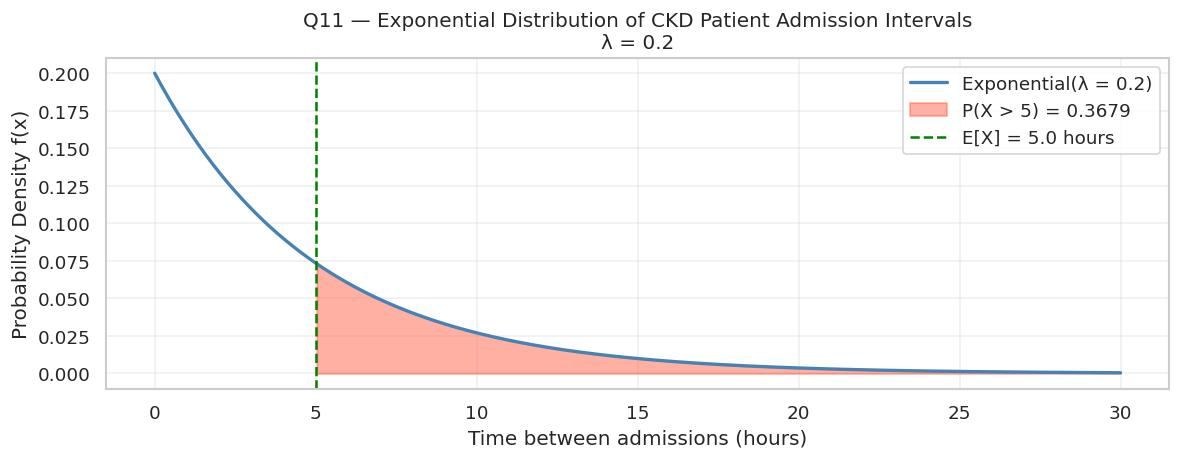


--- Healthcare Interpretation ---
The expected waiting time between consecutive CKD patient admissions is 5.00 hours.
The probability that the next CKD patient arrives after more than 5 hours is 36.79%.
This result can help hospitals estimate patient flow, plan staffing, and allocate nephrology-related resources more effectively.


In [36]:
print('=' * 65)
print('QUESTION 11 — Exponential Distribution (Patient Admission Intervals)')
print('=' * 65)

from scipy.stats import expon

lam = 0.20
scale = 1 / lam

P_gt_5 = expon.sf(
    5,
    scale=scale
)

expected = scale
variance = scale ** 2

print(f'\nParameters: λ = {lam} per hour')
print(f'Scale = 1/λ = {scale:.2f} hours')
print(f'X ~ Exponential(λ = {lam})')

print(
    f'\nPDF: f(x) = λe^(-λx) = {lam}e^(-{lam}x), for x ≥ 0'
)

print(f'P(X > 5) = e^(-λ×5) = e^(-{lam * 5:.2f}) = {P_gt_5:.4f}')
print(f'E[X]     = 1/λ  = {expected:.2f} hours')
print(f'Var[X]   = 1/λ² = {variance:.2f} hours²')

x_e = np.linspace(
    0,
    30,
    400
)

y_e = expon.pdf(
    x_e,
    scale=scale
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    x_e,
    y_e,
    color='steelblue',
    linewidth=2,
    label=f'Exponential(λ = {lam})'
)

x_fill = x_e[x_e >= 5]

ax.fill_between(
    x_fill,
    expon.pdf(x_fill, scale=scale),
    color='tomato',
    alpha=0.5,
    label=f'P(X > 5) = {P_gt_5:.4f}'
)

ax.axvline(
    expected,
    color='green',
    linestyle='--',
    linewidth=1.5,
    label=f'E[X] = {expected:.1f} hours'
)

ax.set_title(
    f'Q11 — Exponential Distribution of CKD Patient Admission Intervals\n'
    f'λ = {lam}'
)

ax.set_xlabel('Time between admissions (hours)')
ax.set_ylabel('Probability Density f(x)')
ax.legend()

plt.tight_layout()

plt.savefig(
    '../figures/Q11_exponential.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    f'The expected waiting time between consecutive CKD patient admissions '
    f'is {expected:.2f} hours.'
)

print(
    f'The probability that the next CKD patient arrives after more than '
    f'5 hours is {P_gt_5:.2%}.'
)

print(
    'This result can help hospitals estimate patient flow, plan staffing, '
    'and allocate nephrology-related resources more effectively.'
)

---
## Question 12 — Central Limit Theorem

QUESTION 12 — Central Limit Theorem (BloodUrea)

Population: μ = 55 mg/dL, σ = 18 mg/dL
Sample size: n = 36

By CLT: X̄ ~ N(μ, σ²/n) = N(55, 18²/36)

Mean of sampling distribution: μ_X̄ = 55
Standard Error: SE = σ/√n = 18/√36 = 3.0000

Z-score for X̄ = 60: Z = (60 - 55) / 3.0000 = 1.6667
P(X̄ > 60) = P(Z > 1.6667) = 0.0478 = 4.78%


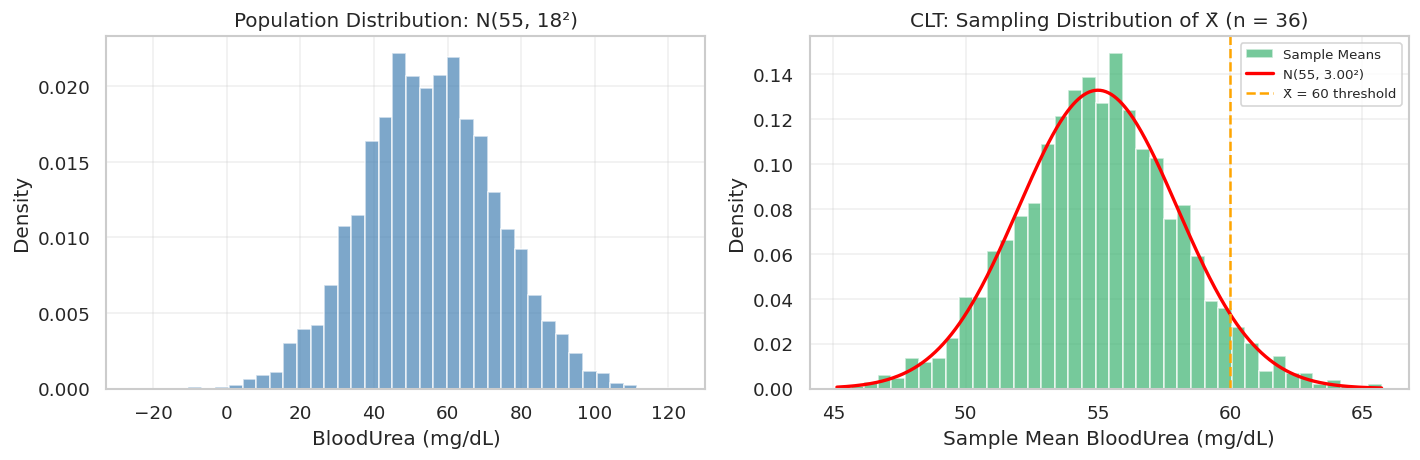


--- Healthcare Interpretation ---
The Central Limit Theorem allows the sampling distribution of the sample mean BloodUrea level to be approximated by a normal distribution.
There is a 4.78% probability that a sample of 36 patients will have a mean BloodUrea level greater than 60 mg/dL.
This helps healthcare researchers evaluate whether observed average BloodUrea levels are unusually high and may indicate kidney dysfunction in the patient group.


In [37]:
print('=' * 65)
print('QUESTION 12 — Central Limit Theorem (BloodUrea)')
print('=' * 65)

from scipy.stats import norm

mu_bu = 55
sigma_bu = 18
n_sample = 36

mean_sampling = mu_bu
SE = sigma_bu / np.sqrt(n_sample)

z_score = (60 - mu_bu) / SE
P_xbar_gt_60 = 1 - norm.cdf(z_score)

print(f'\nPopulation: μ = {mu_bu} mg/dL, σ = {sigma_bu} mg/dL')
print(f'Sample size: n = {n_sample}')

print(
    f'\nBy CLT: X̄ ~ N(μ, σ²/n) = '
    f'N({mu_bu}, {sigma_bu}²/{n_sample})'
)

print(f'\nMean of sampling distribution: μ_X̄ = {mean_sampling}')
print(f'Standard Error: SE = σ/√n = {sigma_bu}/√{n_sample} = {SE:.4f}')

print(
    f'\nZ-score for X̄ = 60: '
    f'Z = (60 - {mu_bu}) / {SE:.4f} = {z_score:.4f}'
)

print(
    f'P(X̄ > 60) = P(Z > {z_score:.4f}) '
    f'= {P_xbar_gt_60:.4f} = {P_xbar_gt_60:.2%}'
)

np.random.seed(42)

sample_means = [
    np.mean(
        np.random.normal(
            mu_bu,
            sigma_bu,
            n_sample
        )
    )
    for _ in range(2000)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pop_vals = np.random.normal(
    mu_bu,
    sigma_bu,
    5000
)

axes[0].hist(
    pop_vals,
    bins=40,
    color='steelblue',
    edgecolor='white',
    density=True,
    alpha=0.7
)

axes[0].set_title(
    f'Population Distribution: N({mu_bu}, {sigma_bu}²)'
)

axes[0].set_xlabel('BloodUrea (mg/dL)')
axes[0].set_ylabel('Density')

axes[1].hist(
    sample_means,
    bins=40,
    color='mediumseagreen',
    edgecolor='white',
    density=True,
    alpha=0.7,
    label='Sample Means'
)

x_norm = np.linspace(
    min(sample_means),
    max(sample_means),
    400
)

axes[1].plot(
    x_norm,
    norm.pdf(
        x_norm,
        mean_sampling,
        SE
    ),
    color='red',
    linewidth=2,
    label=f'N({mu_bu}, {SE:.2f}²)'
)

axes[1].axvline(
    60,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label='X̄ = 60 threshold'
)

axes[1].set_title(
    f'CLT: Sampling Distribution of X̄ (n = {n_sample})'
)

axes[1].set_xlabel('Sample Mean BloodUrea (mg/dL)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

plt.tight_layout()

plt.savefig(
    '../figures/Q12_CLT.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

print('\n--- Healthcare Interpretation ---')

print(
    'The Central Limit Theorem allows the sampling distribution of the '
    'sample mean BloodUrea level to be approximated by a normal distribution.'
)

print(
    f'There is a {P_xbar_gt_60:.2%} probability that a sample of '
    f'{n_sample} patients will have a mean BloodUrea level greater than '
    '60 mg/dL.'
)

print(
    'This helps healthcare researchers evaluate whether observed average '
    'BloodUrea levels are unusually high and may indicate kidney dysfunction '
    'in the patient group.'
)